# Experiment: Rotational Cooling OBE And Benchmarks

Objective:
- Rebuild the large fixed-basis rotational-cooling system from `rotational_cooling.ipynb`.
- Run a 200 us Lindblad solve, plot the resulting dynamics, and benchmark the current Rust-backed solver options.
- Make the initial state choice explicit so the dynamics are visible rather than accidentally starting in a weakly coupled or dark basis state.


In [1]:
from __future__ import annotations

import math
import time

import matplotlib.pyplot as plt
import numpy as np

from centrex_tlf import couplings, lindblad, states, transitions
from centrex_tlf.lindblad.solve import solve_lindblad
from centrex_tlf.utils.population import generate_thermal_population_states

plt.rcParams.update({"font.size": 14})


## Plan

- Use the same three-transition construction as the original notebook.
- Build the benchmark parameter dictionary from the exact `system.coupling_symbols` and `system.polarization_symbols`, not from string-prefix guesses.
- Start from a thermal population in the ground `X`-state manifold using the existing population utility, then renormalize `rho0` explicitly before solving.
- Plot basis-state populations, J-manifold transfer, and the total ground-vs-excited population so optical pumping is visible.
- Benchmark `RK45`, `BDF` with and without the exact Rust Jacobian, and `Radau` with the exact Rust Jacobian using the same thermal initial condition.


In [2]:
# Build the rotational-cooling system from the original notebook
build_start = time.perf_counter()

P2 = transitions.OpticalTransition(transitions.OpticalTransitionType.P, 2, 3 / 2, 1)
J12 = transitions.MicrowaveTransition(1, 2)
J23 = transitions.MicrowaveTransition(2, 3)
transition_selectors = couplings.generate_transition_selectors(
    [P2, J12, J23],
    [
        [couplings.polarization_Z],
        [
            (couplings.polarization_X - couplings.polarization_Z).normalize(),
            couplings.polarization_Y,
        ],
        [
            (couplings.polarization_X + couplings.polarization_Z).normalize(),
            couplings.polarization_Y,
        ],
    ],
)
system = lindblad.generate_OBE_system_transitions(
    [P2, J12, J23], transition_selectors, method="matrix"
)

build_seconds = time.perf_counter() - build_start
print(
    {
        "n_states": len(system.QN),
        "n_couplings": len(system.couplings),
        "n_collapse": int(system.C_array.shape[0]),
        "build_seconds": build_seconds,
    }
)


{'n_states': 67, 'n_couplings': 3, 'n_collapse': 39, 'build_seconds': 144.00223969999934}


In [3]:
# Benchmark-point parameters
def make_benchmark_parameters(
    obe_system, omega_scale=2 * math.pi * 1e6, polarization_scale=1.0, default_other=0.0
):
    parameters = {
        str(symbol): default_other for symbol in obe_system.H_symbolic.free_symbols
    }
    for symbol in obe_system.coupling_symbols:
        parameters[str(symbol)] = omega_scale
    for group in obe_system.polarization_symbols:
        if isinstance(group, (list, tuple)):
            for symbol in group:
                parameters[str(symbol)] = polarization_scale
        else:
            parameters[str(group)] = polarization_scale
    return parameters


parameters = make_benchmark_parameters(system)
print(
    {
        "coupling_symbols": [str(symbol) for symbol in system.coupling_symbols],
        "polarization_symbols": [
            [str(symbol) for symbol in group]
            if isinstance(group, (list, tuple))
            else str(group)
            for group in system.polarization_symbols
        ],
    }
)
parameters


{'coupling_symbols': ['Ω0', 'Ω1', 'Ω2'], 'polarization_symbols': [['PZ0'], ['PA1', 'PY1'], ['PA2', 'PY2']]}


{'δ0': 0.0,
 'PY1': 1.0,
 'PY2': 1.0,
 'Ω0': 6283185.307179586,
 'δ1': 0.0,
 'δ2': 0.0,
 'Ω1': 6283185.307179586,
 'PA2': 1.0,
 'PA1': 1.0,
 'PZ0': 1.0,
 'Ω2': 6283185.307179586}

In [4]:
# Thermal initial state in the ground X manifold
temperature = 4.0
rho0 = generate_thermal_population_states(temperature, system.QN)
rho0 = rho0 / np.trace(rho0)

ground_indices = []
excited_indices = []
j_groups = {}
for idx, state in enumerate(system.QN):
    largest = getattr(state, "largest", state)
    if getattr(largest, "electronic_state", None) == states.ElectronicState.X:
        ground_indices.append(idx)
    else:
        excited_indices.append(idx)
    j_groups.setdefault(str(largest.J), []).append(idx)

initial_populations = np.real(np.diag(rho0))
print(
    {
        "temperature_K": temperature,
        "trace": float(np.trace(rho0).real),
        "ground_population": float(initial_populations[ground_indices].sum()),
        "excited_population": float(initial_populations[excited_indices].sum()),
        "J_populations": {
            label: float(initial_populations[indices].sum())
            for label, indices in sorted(j_groups.items())
        },
    }
)


{'temperature_K': 4.0, 'trace': 1.0, 'ground_population': 1.0, 'excited_population': 0.0, 'J_populations': {'0': 0.10717127406100282, '1': 0.27397855829958506, '2': 0.3315882868501648, '3': 0.2872618807892475}}


## OBE Solve

This solve uses the Rust-backed `solve_ivp` path with the structured Lindblad backend and the corrected benchmark parameter mapping.
The initial condition is a normalized thermal population over the ground `X`-state manifold.


In [5]:
t_span = (0.0, 200e-6)
saveat = np.linspace(t_span[0], t_span[1], 201)

solve_start = time.perf_counter()
result = solve_lindblad(
    system,
    rho0,
    t_span,
    parameters=parameters,
    backend="rust",
    solver="scipy",
    execution_mode="structured",
    saveat=saveat,
    dt=1e-10,
    reltol=1e-7,
    abstol=1e-9,
)
solve_seconds = time.perf_counter() - solve_start
final_populations = result.populations()[-1]
print(
    {
        "solve_seconds": solve_seconds,
        "final_trace": float(final_populations.sum()),
        "final_ground_population": float(final_populations[ground_indices].sum()),
        "final_excited_population": float(final_populations[excited_indices].sum()),
    }
)


{'solve_seconds': 31.98745890002465, 'final_trace': 1.0000000000000004, 'final_ground_population': 0.9998687018847583, 'final_excited_population': 0.00013129811524209778}


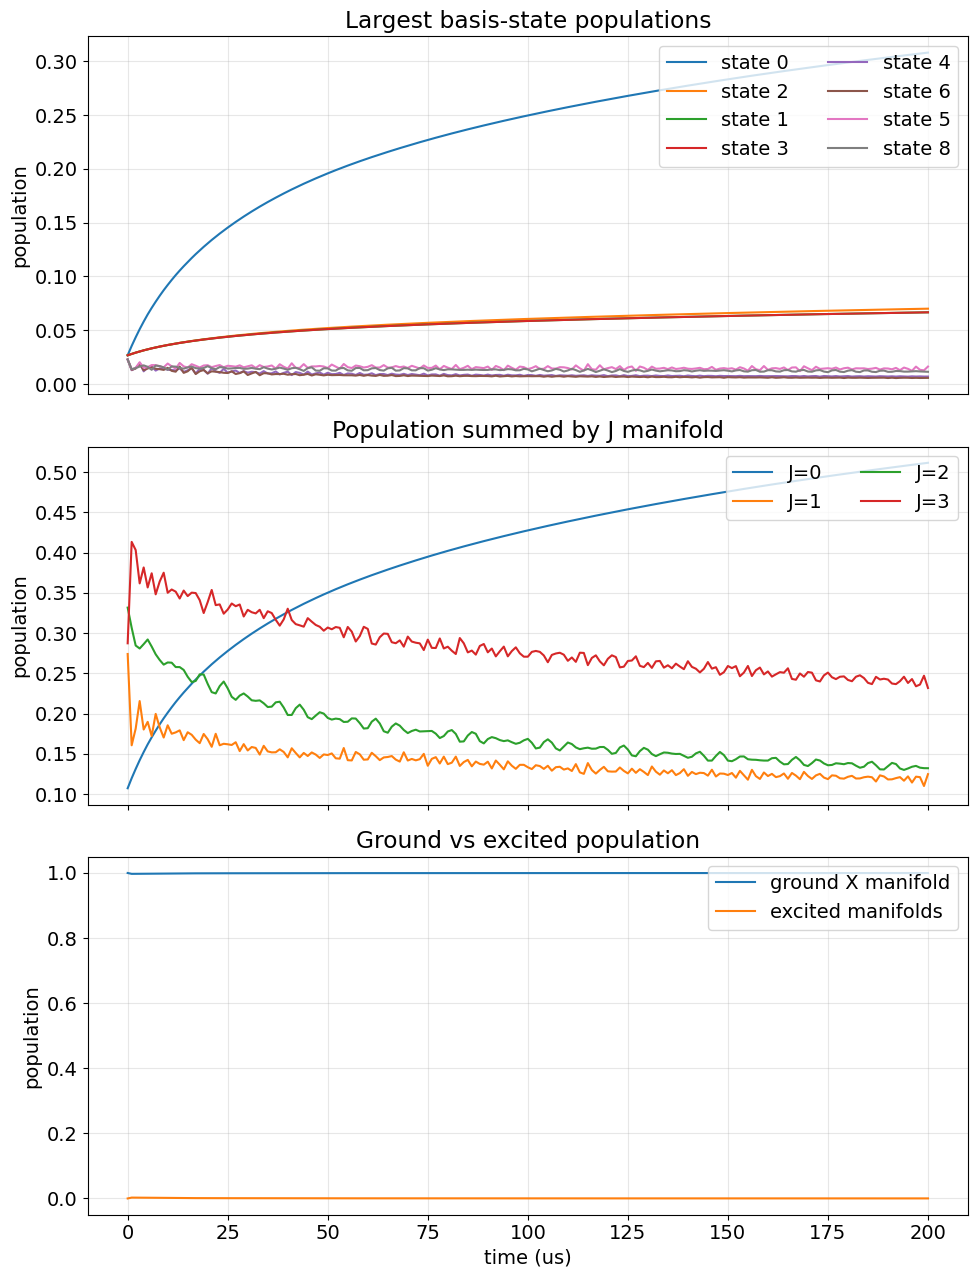

In [6]:
# Plot basis-state, J-manifold, and electronic-manifold populations
populations = result.populations()
time_us = result.t * 1e6

top_indices = np.argsort(populations.max(axis=0))[-8:][::-1]
ground_population = populations[:, ground_indices].sum(axis=1)
excited_population = populations[:, excited_indices].sum(axis=1)

fig, axes = plt.subplots(3, 1, figsize=(10, 13), sharex=True)

for idx in top_indices:
    axes[0].plot(time_us, populations[:, idx], label=f"state {idx}")
axes[0].set_ylabel("population")
axes[0].set_title("Largest basis-state populations")
axes[0].legend(loc="upper right", ncol=2)
axes[0].grid(alpha=0.3)

for label, indices in sorted(j_groups.items(), key=lambda item: item[0]):
    axes[1].plot(time_us, populations[:, indices].sum(axis=1), label=f"J={label}")
axes[1].set_ylabel("population")
axes[1].set_title("Population summed by J manifold")
axes[1].legend(loc="upper right", ncol=2)
axes[1].grid(alpha=0.3)

axes[2].plot(time_us, ground_population, label="ground X manifold")
axes[2].plot(time_us, excited_population, label="excited manifolds")
axes[2].set_xlabel("time (us)")
axes[2].set_ylabel("population")
axes[2].set_title("Ground vs excited population")
axes[2].legend(loc="upper right")
axes[2].grid(alpha=0.3)

plt.tight_layout()


## Benchmarks

These timings use the same thermal initial condition and corrected parameter mapping as the OBE solve above.
The benchmark omits `BDF` without a Jacobian because SciPy's numerical Jacobian estimation is prohibitively slow for this 67-state problem.
The `BDF` and `Radau` paths below use the exact Rust Jacobian.


In [10]:
benchmark_cases = [
    ("scipy_rk45", dict(backend="rust", solver="scipy", execution_mode="structured")),
    (
        "scipy_bdf_exact",
        dict(
            backend="rust",
            solver="scipy_bdf",
            execution_mode="structured",
            jacobian="exact",
            jacobian_format="sparse",
        ),
    ),
    (
        "scipy_radau_exact",
        dict(
            backend="rust",
            solver="scipy_radau",
            execution_mode="structured",
            jacobian="exact",
            jacobian_format="sparse",
        ),
    ),
]

benchmark_results = []
for label, kwargs in benchmark_cases:
    start = time.perf_counter()
    bench_result = solve_lindblad(
        system,
        rho0,
        t_span,
        parameters=parameters,
        saveat=np.linspace(t_span[0], t_span[1], 21),
        dt=1e-10,
        reltol=1e-7,
        abstol=1e-9,
        **kwargs,
    )
    elapsed = time.perf_counter() - start
    benchmark_results.append(
        {
            "case": label,
            "seconds": elapsed,
            "final_trace": float(bench_result.populations()[-1].sum()),
        }
    )
    print(
        f"[{label}] elapsed: {elapsed:.2f} s | final_trace: {float(bench_result.populations()[-1].sum()):.6f}"
    )

benchmark_results


[scipy_rk45] elapsed: 29.39 s | final_trace: 1.000000
[scipy_bdf_exact] elapsed: 13228.38 s | final_trace: 1.000000


KeyboardInterrupt: 

In [ ]:
labels = [row["case"] for row in benchmark_results]
seconds = [row["seconds"] for row in benchmark_results]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, seconds)
ax.set_ylabel("wall time (s)")
ax.set_title("Rotational-cooling solver benchmarks")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
for bar, value in zip(bars, seconds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom",
    )
plt.xticks(rotation=15)
plt.tight_layout()


## Notes

- The earlier notebook version used a broken parameter-mapping helper that could silently zero out the coherent couplings after substitution. This notebook now builds the benchmark parameters from the exact coupling and polarization symbol lists on the system.
- `generate_thermal_population_states(...)` is renormalized explicitly before propagation here because the current basis can omit some states assumed by the helper normalization.
- The electronic-manifold plot is included specifically to distinguish real optical pumping into excited states from pure decay-only behavior.
- System construction dominates notebook startup time for this example, so rerunning only the solve and benchmark cells is much cheaper than rebuilding from scratch.
